# TopLoc HNSW quality-loss / speedup analysis — **DRAGON, CAST2019**, per M ∈ {16, 32, 64}

**Goal.** For each graph connectivity `M`, find the best speedup TopLoc offers over plain HNSW under a bounded quality loss, then compare the resulting speedups **across M**.

**Definitions.**
* **Baseline anchor** = baseline quality at its stabilization point (first `efSearch` beyond which no larger ef improves the metric by more than `STAB_EPS`).
* **Quality loss** of a TopLoc config = anchor − TopLoc quality (negative = gain).
* **Tolerance (TOL)** = accepted loss: {0.0, 0.005, 0.01}.

**Symmetric comparison.** The floor (anchor − TOL) applies to both systems; each is represented by its cheapest config clearing the floor, so speedup = baseline-ref time / TopLoc time.

This notebook runs the **whole mechanism per M**, prints the paper-style table for each M, then adds a **cross-M comparison** of the best speedups. Each M is compared against *its own* baseline, so the cross-M speedups tell you which M gives TopLoc the largest advantage.

In [ ]:
MODEL = "Snowflake"

# One metrics JSON per M. EDIT these paths to match your files.
# Missing files are skipped, so you can run with only the M values you have.
METRIC_FILES = {
    16: "/home/toploc1/Datasets/toploc1/HNSW_paper1/Dragon/search/results/CAST2019/snowflake_toplocHNSW_metrics16_ct2019.json",
    32:  "/home/toploc1/Datasets/toploc1/HNSW_paper1/Dragon/search/results/CAST2019/snowflake_toplocHNSW_metrics32_ct2019.json",
    64: "/home/toploc1/Datasets/toploc1/HNSW_paper1/Dragon/search/results/CAST2019/snowflake_toplocHNSW_metrics64_ct2019.json",
}

METRICS   = ("NDCG@10", "MRR@10", "NDCG@3")
TOLS      = (0.0, 0.005, 0.01)   # allowed quality loss vs baseline anchor
STAB_EPS  = 0.0005               # improvement below this = stabilized
EPS       = 1e-12

# paper-style / cross-M report settings:
REPORT_MODE = "multi"            # thread mode to report (paper uses one socket)
REPORT_TOL  = 0.0                # tolerance whose winner becomes the TopLoc row

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TIME = "avg_query_time_ms"

# Load one metrics JSON per M. Missing files are skipped with a warning,
# so this notebook runs today with whatever M values you already have
# (e.g. just M=32) and picks up M=16 / M=64 once those grids finish.
FRAMES = {}                      # keyed by M
for m, path in METRIC_FILES.items():
    try:
        with open(path) as f:
            raw = json.load(f)
    except FileNotFoundError:
        print(f"M={m}: FILE NOT FOUND ({path}) -> skipping")
        continue
    df = pd.DataFrame.from_dict(raw, orient="index")
    df.index.name = "config"
    df = df.reset_index()
    df["method"] = np.where(df["config"].str.startswith("toploc"),
                            "TopLoc", "baseline")
    for c in ["efSearch", "up", TIME, *METRICS]:
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    FRAMES[m] = (df[df.method == "baseline"].copy(),
                 df[df.method == "TopLoc"].copy())
    modes = sorted(set(df.thread_mode))
    print(f"M={m}: {len(FRAMES[m][0])} baseline / "
          f"{len(FRAMES[m][1])} TopLoc configs, modes {modes}")

MS = list(FRAMES)                # M values actually loaded
MODES = ["single", "multi"]
if not MS:
    raise SystemExit("No metrics files loaded -- fix METRIC_FILES paths.")
print(f"\nLoaded M values: {MS}")

M=16: 26 baseline / 104 TopLoc configs, modes ['multi', 'single']
M=32: 26 baseline / 104 TopLoc configs, modes ['multi', 'single']
M=64: 26 baseline / 104 TopLoc configs, modes ['multi', 'single']

Loaded M values: [16, 32, 64]


## Analysis functions

In [3]:
def frames(m, mode):
    b, t = FRAMES[m]
    return b[b.thread_mode == mode], t[t.thread_mode == mode]


def stabilized_quality(b, metric):
    """Quality at the first efSearch beyond which no larger ef ever
    improves the metric by more than STAB_EPS."""
    bb = b.sort_values("efSearch")
    vals = bb[metric].to_numpy()
    tail_max = np.maximum.accumulate(vals[::-1])[::-1]
    for i, v in enumerate(vals):
        if tail_max[i] - v <= STAB_EPS + EPS:
            return float(v), int(bb["efSearch"].iloc[i])
    return float(vals[-1]), int(bb["efSearch"].iloc[-1])


def cheapest_clearing(rows, floors):
    """Cheapest config whose quality is >= floor on every listed metric."""
    ok = rows
    for m, f in floors.items():
        ok = ok[ok[m] >= f - EPS]
    return None if ok.empty else ok.loc[ok[TIME].idxmin()]


def quality_loss_table(m, mode, metric, tol):
    """Per-metric analysis for one M, mode, tolerance."""
    b, t = frames(m, mode)
    plateau, anchor_ef = stabilized_quality(b, metric)
    floor = plateau - tol
    base_ref = cheapest_clearing(b, {metric: floor})
    qual = t[t[metric] >= floor - EPS].copy()

    tbl = pd.DataFrame({
        "up": qual["up"].astype(int),
        "ef": qual["efSearch"].astype(int),
        f"TopLoc {metric}": qual[metric],
        f"baseline {metric}": base_ref[metric],
        "quality loss": plateau - qual[metric],
        "TopLoc ms/query": qual[TIME],
        "baseline ms/query": base_ref[TIME],
        "speedup": base_ref[TIME] / qual[TIME],
    }).sort_values("speedup", ascending=False).reset_index(drop=True)

    info = {"baseline anchor (stabilized)": f"{plateau:.4f} (at ef={anchor_ef})",
            "TOL (allowed loss)": tol,
            "quality floor": floor,
            "baseline ref (cheapest >= floor)":
                f"ef={int(base_ref['efSearch'])} "
                f"({base_ref[TIME]:.3f} ms/query, {metric}={base_ref[metric]:.4f})"}
    return tbl, info


def quality_loss_table_all(m, mode, tol):
    """Combined: loss must stay within `tol` on ALL three metrics at once."""
    b, t = frames(m, mode)
    plateaus = {mm: b[mm].max() for mm in METRICS}
    floors = {mm: plateaus[mm] - tol for mm in METRICS}
    base_ref = cheapest_clearing(b, floors)

    qual = t
    for mm in METRICS:
        qual = qual[qual[mm] >= floors[mm] - EPS]
    qual = qual.copy()

    info = {**{f"floor {mm}": floors[mm] for mm in METRICS},
            "TOL (allowed loss)": tol}
    if base_ref is None:
        info["note"] = "no baseline config clears all floors"
        return pd.DataFrame(), info
    info["baseline ref (cheapest >= all floors)"] = (
        f"ef={int(base_ref['efSearch'])} ({base_ref[TIME]:.3f} ms/query)")
    if qual.empty:
        return pd.DataFrame(), info

    tbl = pd.DataFrame({
        "up": qual["up"].astype(int),
        "ef": qual["efSearch"].astype(int),
        **{f"TopLoc {mm}": qual[mm] for mm in METRICS},
        **{f"loss {mm}": plateaus[mm] - qual[mm] for mm in METRICS},
        "TopLoc ms/query": qual[TIME],
        "baseline ms/query": base_ref[TIME],
        "speedup": base_ref[TIME] / qual[TIME],
    }).sort_values("speedup", ascending=False).reset_index(drop=True)
    return tbl, info


def show_best(tbl, col="speedup"):
    if tbl.empty:
        print("  (no qualifying configs)")
        return
    try:
        mask = tbl[col] == tbl[col].max()
        display(tbl.style
                   .apply(lambda r: ["background-color:#0b6e4f;color:white"
                                     if mask.loc[r.name] else "" for _ in r],
                          axis=1)
                   .format(precision=4))
    except Exception:
        display(tbl.round(4))

## Combined analysis — all three metrics at once (per M)

In [4]:
for m in MS:
    for mode in MODES:
        for tol in TOLS:
            tbl, info = quality_loss_table_all(m, mode, tol)
            print(f"\n{'=' * 78}\n[{MODEL} M={m} | {mode}] ALL THREE METRICS "
                  f"| TOL = {tol}\n{'=' * 78}")
            for k, v in info.items():
                print(f"  {k:<32}: {v if isinstance(v, str) else f'{v:.4f}'}")
            show_best(tbl.head(5))


[Snowflake M=16 | single] ALL THREE METRICS | TOL = 0.0
  floor NDCG@10                   : 0.4936
  floor MRR@10                    : 0.8013
  floor NDCG@3                    : 0.5420
  TOL (allowed loss)              : 0.0000
  baseline ref (cheapest >= all floors): ef=2048 (27.641 ms/query)


,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,2,32,0.4964,0.8030,0.5447,-0.0028,-0.0016,-0.0027,0.5150,27.6406,53.6713
1,4,32,0.4964,0.8030,0.5447,-0.0028,-0.0016,-0.0027,0.6012,27.6406,45.9742
2,8,32,0.4964,0.8030,0.5447,-0.0028,-0.0016,-0.0027,0.7416,27.6406,37.2695
3,2,64,0.4969,0.8021,0.5441,-0.0032,-0.0008,-0.0021,0.9820,27.6406,28.1470
4,16,32,0.4964,0.8030,0.5447,-0.0028,-0.0016,-0.0027,1.1140,27.6406,24.8124



[Snowflake M=16 | single] ALL THREE METRICS | TOL = 0.005
  floor NDCG@10                   : 0.4886
  floor MRR@10                    : 0.7963
  floor NDCG@3                    : 0.5370
  TOL (allowed loss)              : 0.0050
  baseline ref (cheapest >= all floors): ef=2048 (27.641 ms/query)


,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,2,16,0.4907,0.8016,0.5447,0.0029,-0.0003,-0.0027,0.3079,27.6406,89.7608
1,4,16,0.4907,0.8016,0.5447,0.0029,-0.0003,-0.0027,0.3436,27.6406,80.4385
2,8,16,0.4907,0.8016,0.5447,0.0029,-0.0003,-0.0027,0.4193,27.6406,65.9272
3,2,32,0.4964,0.8030,0.5447,-0.0028,-0.0016,-0.0027,0.5150,27.6406,53.6713
4,4,32,0.4964,0.8030,0.5447,-0.0028,-0.0016,-0.0027,0.6012,27.6406,45.9742



[Snowflake M=16 | single] ALL THREE METRICS | TOL = 0.01
  floor NDCG@10                   : 0.4836
  floor MRR@10                    : 0.7913
  floor NDCG@3                    : 0.5320
  TOL (allowed loss)              : 0.0100
  baseline ref (cheapest >= all floors): ef=512 (6.396 ms/query)


...

,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,2,512,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,1.5526,3.2973,2.1238
1,4,512,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,2.5761,3.2973,1.2799
2,2,1024,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,3.5114,3.2973,0.9390
3,8,512,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,6.8481,3.2973,0.4815
4,4,1024,0.5017,0.8129,0.5493,0.0000,0.0000,0.0000,7.4556,3.2973,0.4423



[Snowflake M=64 | multi] ALL THREE METRICS | TOL = 0.005
  floor NDCG@10                   : 0.4967
  floor MRR@10                    : 0.8079
  floor NDCG@3                    : 0.5443
  TOL (allowed loss)              : 0.0050
  baseline ref (cheapest >= all floors): ef=512 (3.297 ms/query)


,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,4,16,0.4994,0.8081,0.5474,0.0022,0.0048,0.0019,0.1918,3.2973,17.1937
1,2,16,0.4994,0.8081,0.5474,0.0022,0.0048,0.0019,0.1926,3.2973,17.1173
2,8,16,0.4994,0.8081,0.5474,0.0022,0.0048,0.0019,0.2074,3.2973,15.8987
3,4,32,0.4999,0.8081,0.5464,0.0017,0.0048,0.0029,0.2082,3.2973,15.8381
4,2,32,0.4999,0.8081,0.5464,0.0017,0.0048,0.0029,0.2228,3.2973,14.7993



[Snowflake M=64 | multi] ALL THREE METRICS | TOL = 0.01
  floor NDCG@10                   : 0.4917
  floor MRR@10                    : 0.8029
  floor NDCG@3                    : 0.5393
  TOL (allowed loss)              : 0.0100
  baseline ref (cheapest >= all floors): ef=512 (3.297 ms/query)


,up,ef,TopLoc NDCG@10,TopLoc MRR@10,TopLoc NDCG@3,loss NDCG@10,loss MRR@10,loss NDCG@3,TopLoc ms/query,baseline ms/query,speedup
0,4,16,0.4994,0.8081,0.5474,0.0022,0.0048,0.0019,0.1918,3.2973,17.1937
1,2,16,0.4994,0.8081,0.5474,0.0022,0.0048,0.0019,0.1926,3.2973,17.1173
2,8,16,0.4994,0.8081,0.5474,0.0022,0.0048,0.0019,0.2074,3.2973,15.8987
3,4,32,0.4999,0.8081,0.5464,0.0017,0.0048,0.0029,0.2082,3.2973,15.8381
4,2,32,0.4999,0.8081,0.5464,0.0017,0.0048,0.0029,0.2228,3.2973,14.7993


## Iso-quality trade-off plots (per M)

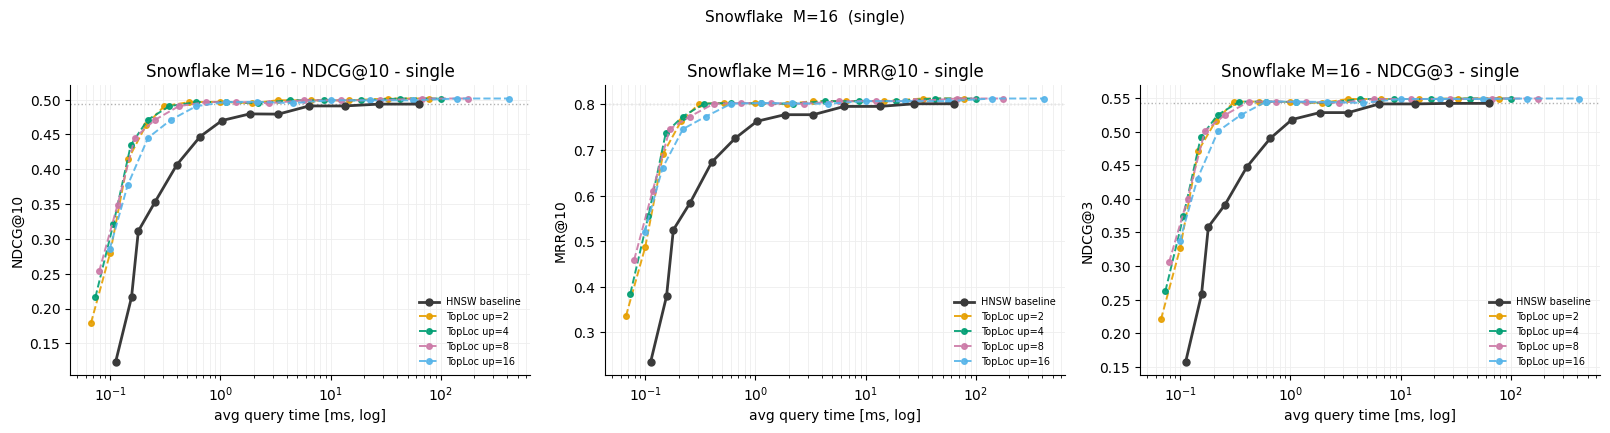

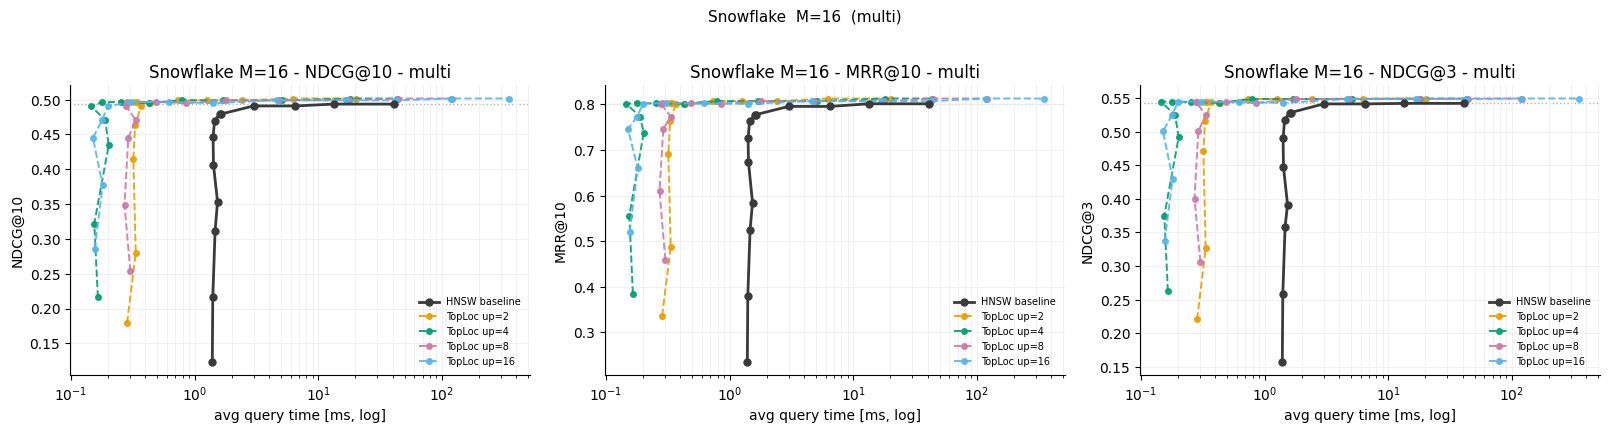

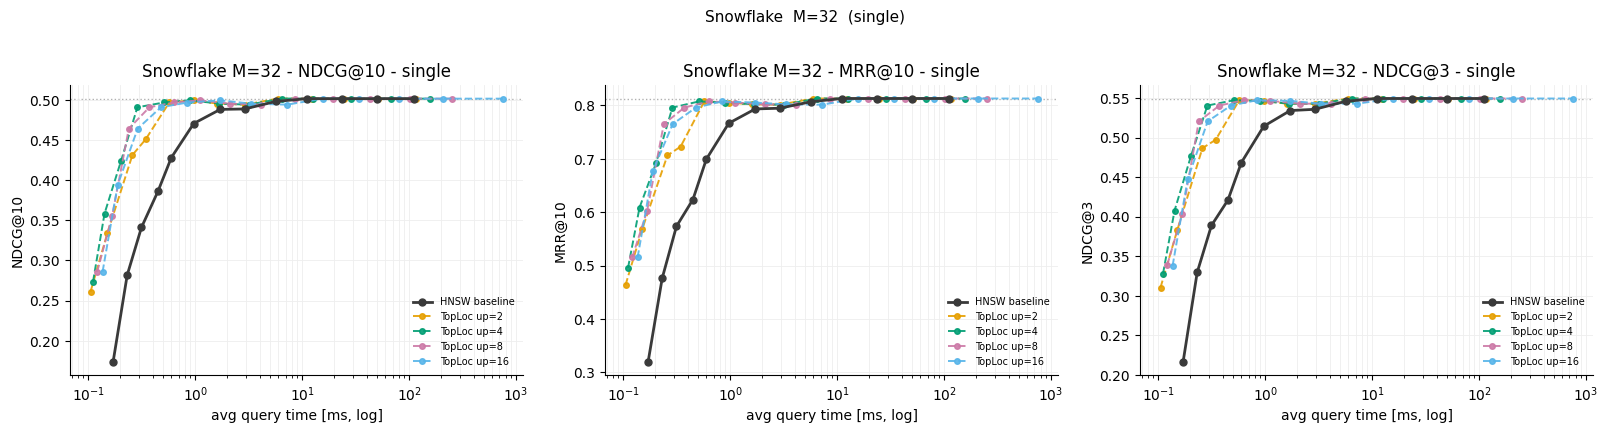

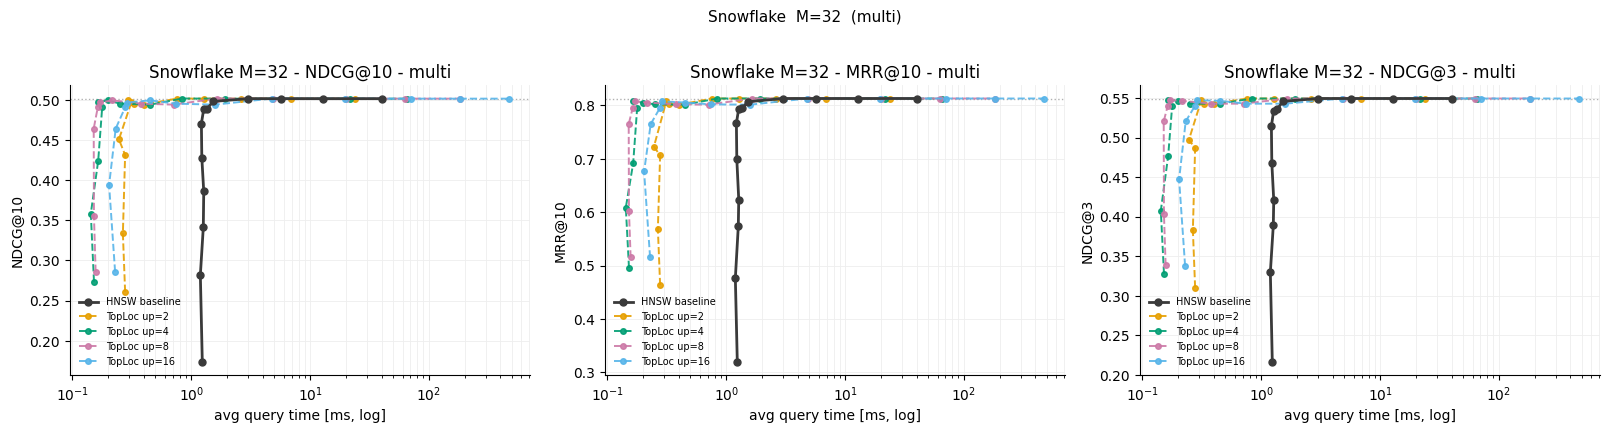

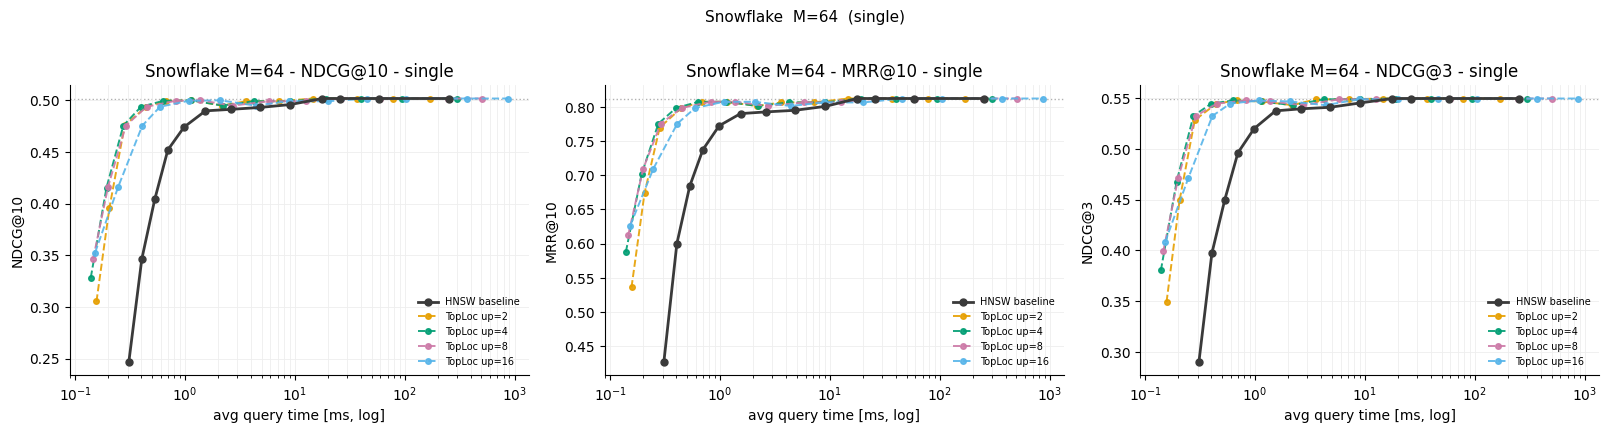

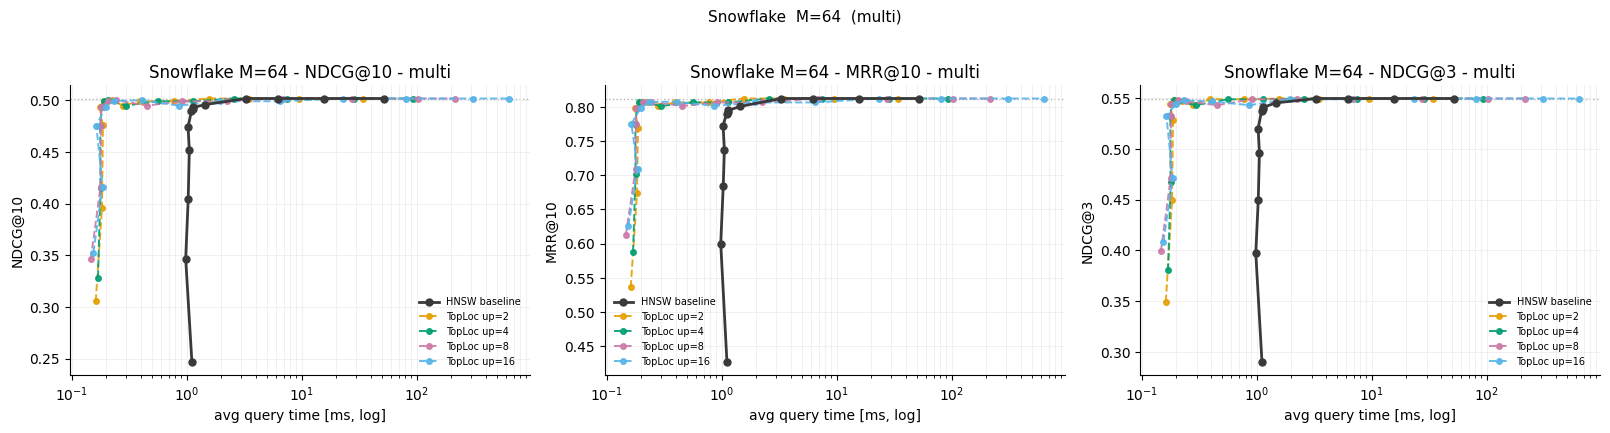

In [5]:
UP_COLORS = {1: "#0072B2", 2: "#E69F00", 4: "#009E73",
             8: "#CC79A7", 16: "#56B4E9"}   # Okabe-Ito, fixed per up


def plot_metric(m, mode, metric, ax):
    b, t = frames(m, mode)
    b = b.sort_values("efSearch")
    ax.plot(b[TIME], b[metric], "-o", color="#3a3a3a", lw=2, ms=5,
            label="HNSW baseline", zorder=3)
    for up in sorted(t["up"].dropna().unique()):
        g = t[t["up"] == up].sort_values("efSearch")
        ax.plot(g[TIME], g[metric], "--o", lw=1.4, ms=4, alpha=0.9,
                color=UP_COLORS.get(int(up), "#888888"),
                label=f"TopLoc up={int(up)}")
    anchor, _ = stabilized_quality(b, metric)
    ax.axhline(anchor, color="#b0b0b0", lw=1, ls=":", zorder=1)
    ax.set_xscale("log")
    ax.set_xlabel("avg query time [ms, log]")
    ax.set_ylabel(metric)
    ax.set_title(f"{MODEL} M={m} - {metric} - {mode}")
    ax.grid(True, which="both", color="#eeeeee", lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(fontsize=7, frameon=False)


for m in MS:
    for mode in MODES:
        fig, axes = plt.subplots(1, len(METRICS),
                                 figsize=(5.4 * len(METRICS), 4.2))
        for ax, metric in zip(np.atleast_1d(axes), METRICS):
            plot_metric(m, mode, metric, ax)
        fig.suptitle(f"{MODEL}  M={m}  ({mode})", y=1.02, fontsize=11)
        fig.tight_layout()
        plt.show()

## Paper-style HNSW table (per M + all-M stacked)

One plain-HNSW row and one TopLoc row per M, average query time in msec, speedup in parentheses. HNSW is the cheapest baseline clearing the same quality floor as TopLoc (symmetric, tolerance-matched).

In [6]:
def paper_rows_for_M(m, mode=None, tol=None):
    """Return the two paper-style rows (HNSW + TopLoc) for one M, or None."""
    mode = mode or REPORT_MODE
    tol = REPORT_TOL if tol is None else tol
    b, t = frames(m, mode)
    tbl, info = quality_loss_table_all(m, mode, tol)
    if tbl.empty:
        print(f"M={m}: no qualifying config at TOL={tol}")
        return None
    best = tbl.iloc[0]
    matched_ms = float(best["baseline ms/query"])
    matched_ref = b.loc[(b[TIME] - matched_ms).abs().idxmin()]
    sp = matched_ms / float(best["TopLoc ms/query"])
    print(f"M={m}: TOL={tol} -> speedup {sp:.2f}x "
          f"(matched baseline ef={int(matched_ref['efSearch'])}, mode={mode})")
    rows = [
        {"M": m, "Search": f"HNSW (ef={int(matched_ref['efSearch'])})",
         "MRR@10": float(matched_ref["MRR@10"]),
         "NDCG@3": float(matched_ref["NDCG@3"]),
         "NDCG@10": float(matched_ref["NDCG@10"]),
         "Time (ms)": f"{matched_ref[TIME]:.3f}   (-)"},
        {"M": m, "Search": f"TopLoc HNSW (up={int(best['up'])}, ef={int(best['ef'])})",
         "MRR@10": float(best["TopLoc MRR@10"]),
         "NDCG@3": float(best["TopLoc NDCG@3"]),
         "NDCG@10": float(best["TopLoc NDCG@10"]),
         "Time (ms)": f"{best['TopLoc ms/query']:.3f}   ({sp:.1f}x)"},
    ]
    return pd.DataFrame(rows)


# --- one paper-style table PER M (like the end of the original notebook) ---
print(f"{MODEL} - TREC CAsT 2019 - paper-style table per M "
      f"[{REPORT_MODE}-thread, TOL={REPORT_TOL}]\n")
per_m_tables = []
for m in MS:
    dfm = paper_rows_for_M(m)
    if dfm is not None:
        per_m_tables.append(dfm)
        display(dfm.set_index(["M", "Search"]).round(4))

# --- one combined table stacking every M (general side-by-side) ---
if per_m_tables:
    all_m = pd.concat(per_m_tables).set_index(["M", "Search"]).round(4)
    print("\nAll M values stacked:")
    display(all_m)
    all_m.to_csv(f"hnsw_table_{MODEL}_2019.csv")

Snowflake - TREC CAsT 2019 - paper-style table per M [multi-thread, TOL=0.0]

M=16: TOL=0.0 -> speedup 75.06x (matched baseline ef=2048, mode=multi)


MRR@10  NDCG@3  NDCG@10        Time (ms)
M  Search                                                             
16 HNSW (ef=2048)             0.8013  0.5420   0.4936     13.492   (-)
   TopLoc HNSW (up=4, ef=32)  0.8030  0.5447   0.4964  0.180   (75.1x)

M=32: TOL=0.0 -> speedup 3.98x (matched baseline ef=512, mode=multi)


MRR@10  NDCG@3  NDCG@10       Time (ms)
M  Search                                                             
32 HNSW (ef=512)               0.8129  0.5493   0.5017     3.030   (-)
   TopLoc HNSW (up=2, ef=256)  0.8129  0.5493   0.5019  0.762   (4.0x)

M=64: TOL=0.0 -> speedup 2.12x (matched baseline ef=512, mode=multi)


MRR@10  NDCG@3  NDCG@10       Time (ms)
M  Search                                                             
64 HNSW (ef=512)               0.8129  0.5493   0.5017     3.297   (-)
   TopLoc HNSW (up=2, ef=512)  0.8129  0.5493   0.5017  1.553   (2.1x)


All M values stacked:


MRR@10  NDCG@3  NDCG@10        Time (ms)
M  Search                                                              
16 HNSW (ef=2048)              0.8013  0.5420   0.4936     13.492   (-)
   TopLoc HNSW (up=4, ef=32)   0.8030  0.5447   0.4964  0.180   (75.1x)
32 HNSW (ef=512)               0.8129  0.5493   0.5017      3.030   (-)
   TopLoc HNSW (up=2, ef=256)  0.8129  0.5493   0.5019   0.762   (4.0x)
64 HNSW (ef=512)               0.8129  0.5493   0.5017      3.297   (-)
   TopLoc HNSW (up=2, ef=512)  0.8129  0.5493   0.5017   1.553   (2.1x)

## Global best across all M — best HNSW vs best TopLoc, pooled

Pools every baseline and every TopLoc config from **all** M ∈ {16, 32, 64} into one pool. The quality floor is the best baseline quality achievable at any M, minus the tolerance. The winning baseline is the **fastest** baseline clearing that floor, and the winning TopLoc is the **fastest** TopLoc clearing it — and they may sit at **different M** (e.g. baseline at M=32, TopLoc at M=64). The `base M` and `TopLoc M` columns show which M each winner came from. This is the 'best HNSW you can build vs best TopLoc you can build, at matched quality' number, swept over all three tolerances.

In [7]:
# ============================================================
# GLOBAL best baseline vs best TopLoc, POOLED across all M in MS.
# Combined (all three metrics matched at once) ONLY.
# ============================================================
def pooled(mode):
    B = pd.concat([FRAMES[m][0].assign(M=m) for m in MS], ignore_index=True)
    T = pd.concat([FRAMES[m][1].assign(M=m) for m in MS], ignore_index=True)
    return B[B.thread_mode == mode], T[T.thread_mode == mode]


def global_best(mode, tol, metric=None):
    B, T = pooled(mode)
    if metric is None:                                  # match on all 3 metrics
        floors = {mm: B[mm].max() - tol for mm in METRICS}
        bq, tq = B, T
        for mm in METRICS:
            bq = bq[bq[mm] >= floors[mm] - EPS]
            tq = tq[tq[mm] >= floors[mm] - EPS]
        qcols = list(METRICS)
    else:
        floor = B[metric].max() - tol
        bq = B[B[metric] >= floor - EPS]
        tq = T[T[metric] >= floor - EPS]
        qcols = [metric]
    if bq.empty or tq.empty:
        return None
    bb = bq.loc[bq[TIME].idxmin()]                      # fastest baseline, any M
    tt = tq.loc[tq[TIME].idxmin()]                      # fastest TopLoc,   any M
    row = {"scope": metric or "combined", "TOL": tol,
           "base M": int(bb["M"]), "base ef": int(bb["efSearch"]),
           "base ms": round(float(bb[TIME]), 4),
           "TopLoc M": int(tt["M"]), "TopLoc up": int(tt["up"]),
           "TopLoc ef": int(tt["efSearch"]), "TopLoc ms": round(float(tt[TIME]), 4),
           "speedup": round(float(bb[TIME] / tt[TIME]), 3)}
    for mm in qcols:
        row[f"base {mm}"] = round(float(bb[mm]), 4)
        row[f"TopLoc {mm}"] = round(float(tt[mm]), 4)
    return row


COMPACT = ["scope", "TOL", "base M", "base ef", "base ms",
           "TopLoc M", "TopLoc up", "TopLoc ef", "TopLoc ms", "speedup"]

for mode in MODES:
    print(f"\n{'=' * 78}\n{MODEL} - GLOBAL best baseline vs best TopLoc, pooled over "
          f"M={MS} [{mode}] (all three metrics)\n{'=' * 78}")
    rows = [r for tol in TOLS
            if (r := global_best(mode, tol, None)) is not None]   # combined only
    if not rows:
        print("  (no qualifying configs)")
        continue
    display(pd.DataFrame(rows)[COMPACT].copy())

# --- headline: combined; try REPORT_TOL first, then fall back to looser tolerances ---
candidates = [REPORT_TOL] + [t for t in sorted(TOLS) if t > REPORT_TOL]
hr, used_tol = None, None
for t in candidates:
    hr = global_best(REPORT_MODE, t, None)
    if hr is not None:
        used_tol = t
        break

print(f"\n{'=' * 78}\n{MODEL} HEADLINE - best HNSW vs best TopLoc across all M "
      f"[{REPORT_MODE}]\n{'=' * 78}")
if hr is None:
    print(f"  (no combined match at any tolerance in {sorted(candidates)})")
else:
    if used_tol != REPORT_TOL:
        print(f"  no match at TOL={REPORT_TOL}; reporting first match at TOL={used_tol}")
    print(f"  best baseline: M={hr['base M']} ef={hr['base ef']} "
          f"({hr['base ms']} ms)")
    print(f"  best TopLoc  : M={hr['TopLoc M']} up={hr['TopLoc up']} "
          f"ef={hr['TopLoc ef']} ({hr['TopLoc ms']} ms)")
    print(f"  => speedup {hr['speedup']}x at matched quality (TOL={used_tol})")
    if hr["base M"] != hr["TopLoc M"]:
        print(f"  note: winners come from DIFFERENT M "
              f"(baseline@{hr['base M']}, TopLoc@{hr['TopLoc M']})")
    display(pd.DataFrame([hr]))
    pd.DataFrame([hr]).to_csv(f"global_best_{MODEL}_2019.csv", index=False)


Snowflake - GLOBAL best baseline vs best TopLoc, pooled over M=[16, 32, 64] [single] (all three metrics)


,scope,TOL,base M,base ef,base ms,TopLoc M,TopLoc up,TopLoc ef,TopLoc ms,speedup
0,combined,0.000,32,512,11.0803,32,2,256,5.9707,1.856
1,combined,0.005,32,512,11.0803,64,4,16,0.6330,17.505
2,combined,0.010,32,256,5.6669,32,4,16,0.5106,11.099



Snowflake - GLOBAL best baseline vs best TopLoc, pooled over M=[16, 32, 64] [multi] (all three metrics)


,scope,TOL,base M,base ef,base ms,TopLoc M,TopLoc up,TopLoc ef,TopLoc ms,speedup
0,combined,0.000,32,512,3.0298,32,2,256,0.7622,3.975
1,combined,0.005,32,512,3.0298,64,4,16,0.1918,15.799
2,combined,0.010,32,256,1.5257,32,4,16,0.1640,9.303



Snowflake HEADLINE - best HNSW vs best TopLoc across all M [multi]
  best baseline: M=32 ef=512 (3.0298 ms)
  best TopLoc  : M=32 up=2 ef=256 (0.7622 ms)
  => speedup 3.975x at matched quality (TOL=0.0)


,scope,TOL,base M,base ef,base ms,TopLoc M,TopLoc up,TopLoc ef,TopLoc ms,speedup,base NDCG@10,TopLoc NDCG@10,base MRR@10,TopLoc MRR@10,base NDCG@3,TopLoc NDCG@3
0,combined,0.0,32,512,3.0298,32,2,256,0.7622,3.975,0.5017,0.5019,0.8129,0.8129,0.5493,0.5493


In [8]:
# --- paper-style table: best baseline vs best TopLoc, pooled across all M ---
def global_paper_rows(mode, tol):
    r = global_best(mode, tol, None)          # combined match across all M
    if r is None:
        return None
    return [
        {"TOL": tol,
         "Search": f"HNSW (M={r['base M']}, ef={r['base ef']})",
         "MRR@10": r["base MRR@10"], "NDCG@3": r["base NDCG@3"],
         "NDCG@10": r["base NDCG@10"],
         "Time (ms)": f"{r['base ms']:.3f}   (-)"},
        {"TOL": tol,
         "Search": f"TopLoc HNSW (M={r['TopLoc M']}, up={r['TopLoc up']}, ef={r['TopLoc ef']})",
         "MRR@10": r["TopLoc MRR@10"], "NDCG@3": r["TopLoc NDCG@3"],
         "NDCG@10": r["TopLoc NDCG@10"],
         "Time (ms)": f"{r['TopLoc ms']:.3f}   ({r['speedup']:.1f}x)"},
    ]

# headline: try REPORT_TOL first, then fall back to looser tolerances
candidates = [REPORT_TOL] + [t for t in sorted(TOLS) if t > REPORT_TOL]
hr, used_tol = None, None
for t in candidates:
    hr = global_paper_rows(REPORT_MODE, t)
    if hr:
        used_tol = t
        break

print(f"{MODEL} - GLOBAL best HNSW vs best TopLoc across M={MS} [{REPORT_MODE}]")
if hr:
    if used_tol != REPORT_TOL:
        print(f"  no match at TOL={REPORT_TOL}; reporting first match at TOL={used_tol}")
    else:
        print(f"  TOL={used_tol}")
    display(pd.DataFrame(hr).drop(columns="TOL").set_index("Search")
              [["MRR@10", "NDCG@3", "NDCG@10", "Time (ms)"]])
else:
    print(f"  no combined global match at any tolerance in {sorted(candidates)}")

# same table swept over every tolerance
allrows = [row for tol in TOLS for row in (global_paper_rows(REPORT_MODE, tol) or [])]
if allrows:
    tbl = (pd.DataFrame(allrows).set_index(["TOL", "Search"])
             [["MRR@10", "NDCG@3", "NDCG@10", "Time (ms)"]])
    print("\nAcross tolerances:")
    display(tbl)

Snowflake - GLOBAL best HNSW vs best TopLoc across M=[16, 32, 64] [multi]
  TOL=0.0


,MRR@10,NDCG@3,NDCG@10,Time (ms)
Search,,,,
"HNSW (M=32, ef=512)",0.8129,0.5493,0.5017,3.030 (-)
"TopLoc HNSW (M=32, up=2, ef=256)",0.8129,0.5493,0.5019,0.762 (4.0x)



Across tolerances:


MRR@10  NDCG@3  NDCG@10  \
TOL   Search                                                      
0.000 HNSW (M=32, ef=512)               0.8129  0.5493   0.5017   
      TopLoc HNSW (M=32, up=2, ef=256)  0.8129  0.5493   0.5019   
0.005 HNSW (M=32, ef=512)               0.8129  0.5493   0.5017   
      TopLoc HNSW (M=64, up=4, ef=16)   0.8081  0.5474   0.4994   
0.010 HNSW (M=32, ef=256)               0.8068  0.5458   0.4982   
      TopLoc HNSW (M=32, up=4, ef=16)   0.8075  0.5472   0.4969   

                                              Time (ms)  
TOL   Search                                             
0.000 HNSW (M=32, ef=512)                   3.030   (-)  
      TopLoc HNSW (M=32, up=2, ef=256)   0.762   (4.0x)  
0.005 HNSW (M=32, ef=512)                   3.030   (-)  
      TopLoc HNSW (M=64, up=4, ef=16)   0.192   (15.8x)  
0.010 HNSW (M=32, ef=256)                   1.526   (-)  
      TopLoc HNSW (M=32, up=4, ef=16)    0.164   (9.3x)

## How to read this notebook

Per-metric and combined blocks print the process (anchor, tolerance, floor, matched baseline) then every qualifying TopLoc config sorted by speedup, best highlighted. The paper-style section condenses each M into Table-1 format and stacks all M. The cross-M section compares the best speedups across M — each relative to its own baseline, on the same hardware, so the ratios are directly comparable.